In [16]:
from sample import *
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [17]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [18]:
cd /pi/robert.brown-umw/nl/ozgun/Snehal_HDD/

/pi/robert.brown-umw/nl/ozgun/Snehal_HDD


/home/ozgun.uyan-umw/miniconda3/envs/cooltools054/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [19]:
def compartment_info(fls):
    comb=pd.read_csv("cooltools54/EV1_flipped_versions_v2/"+fls[0]+"_100kb_arms.cis.vecs.tsv",sep='\t')[['chrom','start','end']]
    for f in fls:
        df1=pd.read_csv("cooltools54/EV1_flipped_versions_v2/"+f+"_100kb_arms.cis.vecs.tsv",sep='\t')
        df1[f]='N'
        df1.loc[df1['E1'] > 0.05, f] = 'A'
        df1.loc[df1['E1'] < -0.05, f] = 'B'
        df1=df1[['chrom','start','end',f]]
        print(len(df1))
        comb = pd.merge(comb, df1, on=['chrom','start','end'])
    comb['comp'] = comb.iloc[:, -3:].apply(lambda x: ''.join(x), axis=1)
    comb=comb[['chrom','start','end','comp']]
    #comb.head(20)
    return(comb)

# Control

In [20]:
fls=['OU-HiC-N6-pfib-D4','OU-HiC-N6IPSC1-R1','OU-HiC-N6IPSC1MND45-R2']
n6c1=compartment_info(fls)
n6c1.head(40).tail()
c=n6c1.groupby(['comp'])['comp'].count().reset_index(name='Control-1-Clone-1')
#c

28760
28760
28760


In [21]:
fls=['OU-HiC-N6-pfib-D4','OU-HiC-N6IPSC2-R1','OU-HiC-N6IPSC2MND45-R2']
n6c2=compartment_info(fls)
n6c2.head(20).tail()
c1=n6c2.groupby(['comp'])['comp'].count().reset_index(name='Control-1-Clone-2')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [22]:
fls=['OU-HiC-N9-pfib-D4','OU-HiC-N9IPSC1-R2','OU-HiC-N9IPSC1MND45-R2']
n9c1=compartment_info(fls)
n9c1.head(20).tail()
c1=n9c1.groupby(['comp'])['comp'].count().reset_index(name='Control-2-Clone-1')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [23]:
fls=['OU-HiC-N9-pfib-D4','OU-HiC-N9IPSC2-R1','OU-HiC-N9IPSC2MND45-R2']
n9c2=compartment_info(fls)
n9c2.head(20).tail()
c1=n9c2.groupby(['comp'])['comp'].count().reset_index(name='Control-2-Clone-2')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [24]:
common = n6c1.merge(n6c2).merge(n9c1).merge(n9c2)
len(common)

18098

In [25]:
common.head()
common.to_csv("cooltools54/Comp-transitions/Controls-intersect_EV1_flipped_versions_v2_cut_off_005_no_adjacent.tsv",sep='\t',index=False)

In [26]:
mgd=common.groupby(['comp'])['comp'].count().reset_index(name='intersect')
c=pd.merge(c,mgd,how='outer')
#c

In [27]:
c.set_index('comp', inplace=True)
c_percent = (c / 28760) * 100

In [28]:
c_percent=c_percent.round(1).dropna()
c_percent=c_percent.sort_values(by='intersect',ascending=False)
#c_percent=c_percent.sort_values(by='intersect',ascending=False).head(9)
c_percent

,Control-1-Clone-1,Control-1-Clone-2,Control-2-Clone-1,Control-2-Clone-2,intersect
comp,,,,,
BBB,25.7,25.5,24.8,25.5,19.9
AAA,22.1,20.9,19.5,19.7,16.5
NNN,9.8,9.6,9.3,9.1,9.1
ABB,7.2,7.6,7.5,7.6,4.8
BAA,7.3,7.3,7.4,7.2,4.8
AAB,5.7,5.9,7.1,7.7,2.9
BAB,4.9,4.7,5.0,5.4,2.0
BBA,3.1,4.2,4.3,3.9,1.5
ABA,1.8,2.5,2.1,1.8,0.7


In [29]:
# Flip rows and columns (transpose) and save to TSV

# Assuming c_percent is already defined
c_percent_flipped = c_percent.T

# 2) Reorder columns according to your desired sequence
desired_order = ["AAA", "AAB", "ABB", "ABA", "BBB", "BBA", "BAA", "BAB", "NNN"]
c_percent_reordered = c_percent_flipped[desired_order]

# 3) Save the reordered table to TSV
output_tsv = "cooltools54/EV1_flipped_versions_v2/c_percent_EV1_flipped_v2_flipped_reordered_cutoff_005_noadjacent.tsv"
c_percent_reordered.to_csv(output_tsv, sep="\t", index=True)
print(f"Saved reordered table to {output_tsv}")

# 4) (Optionally) display the result
c_percent_reordered

Saved reordered table to cooltools54/EV1_flipped_versions_v2/c_percent_EV1_flipped_v2_flipped_reordered_cutoff_005_noadjacent.tsv


comp,AAA,AAB,ABB,ABA,BBB,BBA,BAA,BAB,NNN
Control-1-Clone-1,22.1,5.7,7.2,1.8,25.7,3.1,7.3,4.9,9.8
Control-1-Clone-2,20.9,5.9,7.6,2.5,25.5,4.2,7.3,4.7,9.6
Control-2-Clone-1,19.5,7.1,7.5,2.1,24.8,4.3,7.4,5.0,9.3
Control-2-Clone-2,19.7,7.7,7.6,1.8,25.5,3.9,7.2,5.4,9.1
intersect,16.5,2.9,4.8,0.7,19.9,1.5,4.8,2.0,9.1


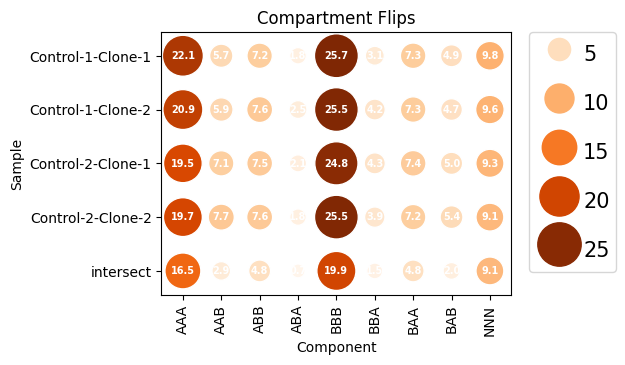

In [30]:
# 1) Load & prepare
df = pd.read_csv(
    "cooltools54/EV1_flipped_versions_v2/c_percent_EV1_flipped_v2_flipped_reordered_cutoff_005_noadjacent.tsv",
    sep="\t",
    index_col=0
)
df.index.name = "Sample"
desired_order = ["AAA","AAB","ABB","ABA","BBB","BBA","BAA","BAB","NNN"]
df = df[desired_order]

# 2) Melt to long form
df_long = (
    df
    .reset_index()
    .melt(id_vars="Sample", var_name="Component", value_name="Percentage")
)
df_long["Component"] = pd.Categorical(
    df_long["Component"],
    categories=desired_order,
    ordered=True
)

# 3) Plot (suppress built‐in legend)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.scatterplot(
    data=df_long,
    x="Component",
    y="Sample",
    size="Percentage",
    sizes=(100, 1000),
    hue="Percentage",
    palette="Oranges",
    legend=True,
    ax=ax
)

# 4) Annotate
for _, row in df_long.iterrows():
    ax.text(
        row["Component"], row["Sample"],
        f"{row['Percentage']:.1f}",
        ha="center", va="center",
        fontsize=7, color="white", weight="bold"
    )
# 5) Add padding/margins
ax.margins(x=0.07, y=0.11)  # 5% horizontal, 10% vertical margin
fig.tight_layout(pad=1.5)   # increase padding around the figure


# 7) Final tweaks
ax.set_ylabel("Sample")
plt.title("Compartment Flips")
plt.xticks(rotation=90)
#plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', borderaxespad=0, ncol=1, fontsize = "small")

plt.legend(
    fontsize=15,
    title_fontsize=12,
    borderaxespad=0,      # padding between legend and axes
    handlelength=2.3,       # length of legend marker
    handleheight=2,
    handletextpad=0,      # space between marker and text
    borderpad=.3,          # padding inside legend box
    labelspacing=0.8,       # vertical space between items
    loc='upper left',
    bbox_to_anchor=(1.05, 1),  # move legend outside plot
    frameon=True
)
plt.subplots_adjust(left=0.2, right=0.7, top=0.90, bottom=0.15)


plt.savefig("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/fig2d_EV1_flipped_v2_comp_flips_cutoff_005_noadjacent.pdf",bbox_inches = 'tight')
plt.show()

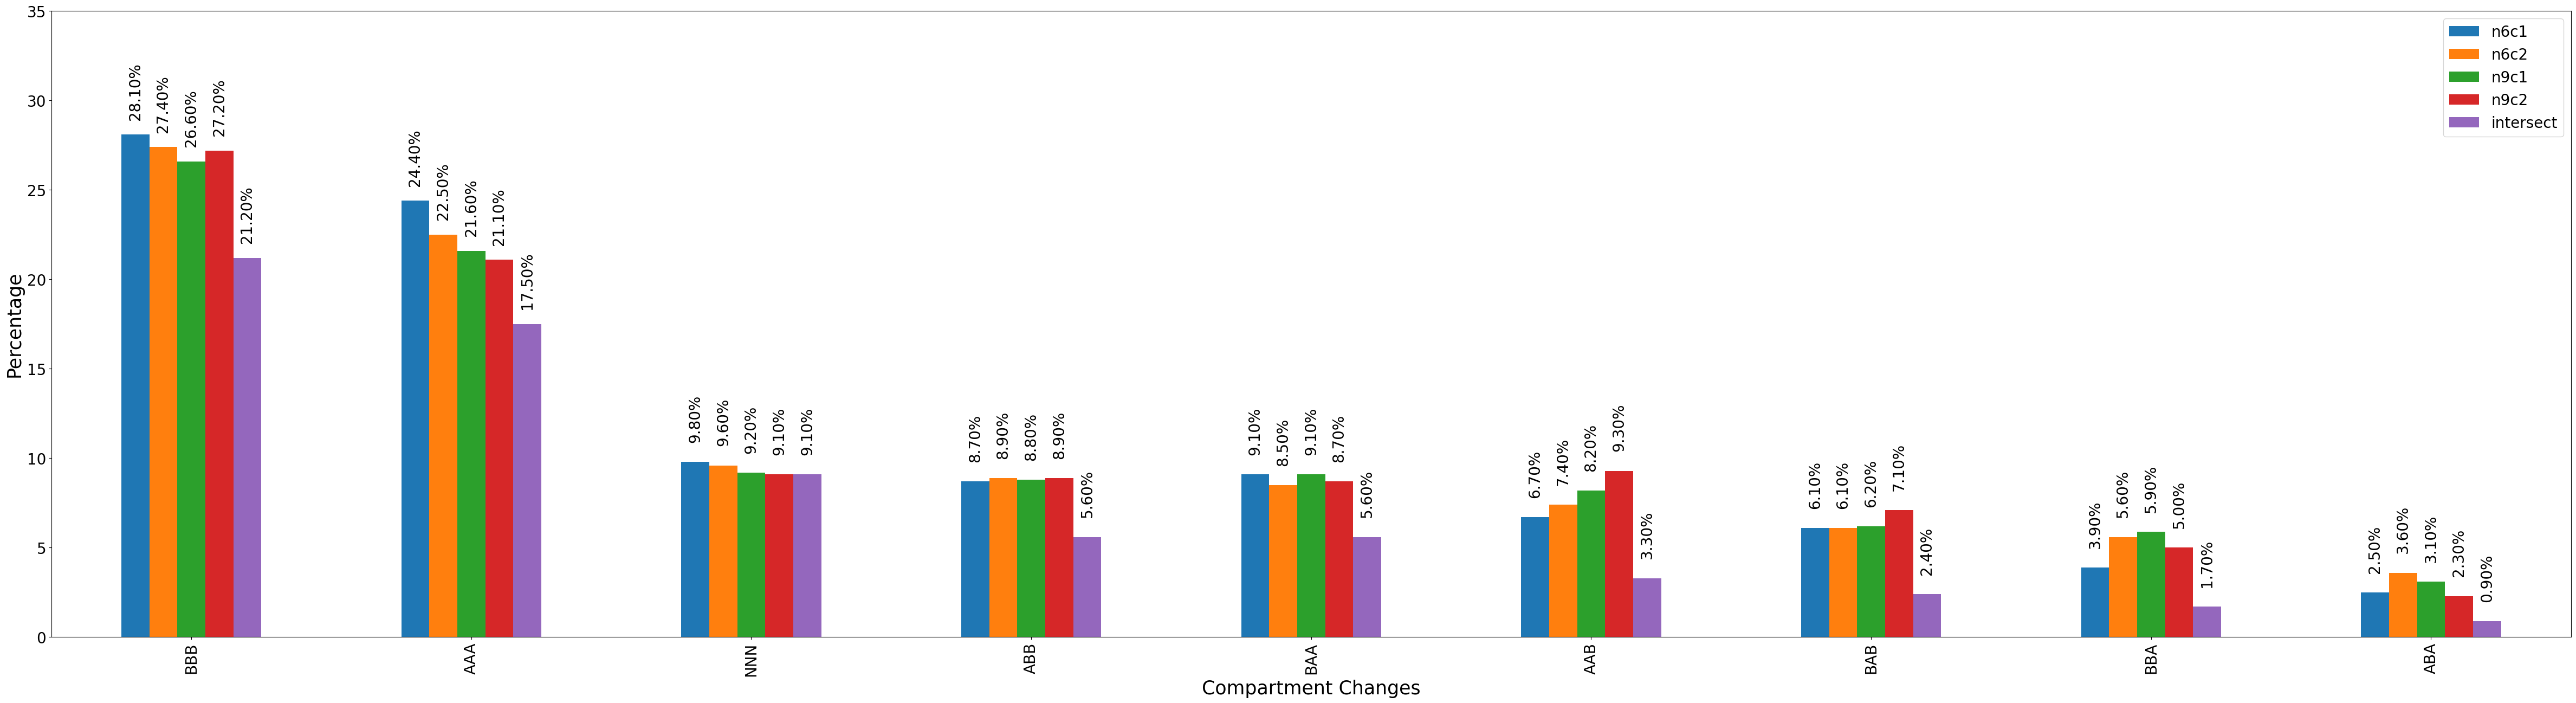

In [14]:
ax=c_percent.plot.bar(rot=90,figsize=(60, 15))
for p in ax.patches:
    value = p.get_height()
    if not pd.isna(value):
        ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()+2),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points',rotation=90,fontsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=20)
ax.set_ylim(0, 35)
ax.set_xlabel('Compartment Changes', fontsize=25)
ax.set_ylabel('Percentage', fontsize=25)
#plt.savefig("cooltools54/Comp-transitions/Controls-compartment-changes-top9.pdf")
plt.show()

# For patients

In [15]:
fls=['OU-HiC-C2-pfib-D4','OU-HiC-C2IPSC1-R1','OU-HiC-C2IPSC1MND45-R1']
c2c1=compartment_info(fls)
c2c1.head(40).tail()
c=c2c1.groupby(['comp'])['comp'].count().reset_index(name='c2c1')
#c

28760
28760
28760


In [16]:
fls=['OU-HiC-C2-pfib-D4','OU-HiC-C2IPSC2-R1','OU-HiC-C2IPSC2MND45-R1']
c2c2=compartment_info(fls)
c2c2.head(40).tail()
c1=c2c2.groupby(['comp'])['comp'].count().reset_index(name='c2c2')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [17]:
fls=['OU-HiC-C3-pfib-D4','OU-HiC-C3IPSC3-R2','OU-HiC-C3IPSC3MND45-R1']
c3c3=compartment_info(fls)
c3c3.head(40).tail()
c1=c3c3.groupby(['comp'])['comp'].count().reset_index(name='c3c3')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [18]:
fls=['OU-HiC-C3-pfib-D4','OU-HiC-C3IPSC4-R1','OU-HiC-C3IPSC4MND45-R1']
c3c4=compartment_info(fls)
c3c4.head(40).tail()
c1=c3c4.groupby(['comp'])['comp'].count().reset_index(name='c3c4')
c=pd.merge(c,c1,how='outer')
#c

28760
28760
28760


In [19]:
common = c2c1.merge(c2c2).merge(c3c3).merge(c3c4)
len(common)

17313

In [20]:
common.head()
#common.to_csv("cooltools54/Comp-transitions/Patients-intersect.tsv",sep='\t',index=False)

,chrom,start,end,comp
0,chr1,0,100000,NNN
1,chr1,100000,200000,NNN
2,chr1,200000,300000,NNN
3,chr1,300000,400000,NNN
4,chr1,400000,500000,NNN


In [21]:
mgd=common.groupby(['comp'])['comp'].count().reset_index(name='intersect')
c=pd.merge(c,mgd,how='outer')
#c

In [22]:
c.set_index('comp', inplace=True)
c_percent = (c / 28760) * 100

In [23]:
c_percent=c_percent.round(1).dropna()
c_percent=c_percent.sort_values(by='intersect',ascending=False).head(9)
c_percent

,c2c1,c2c2,c3c3,c3c4,intersect
comp,,,,,
BBB,28.4,26.4,27.5,25.0,19.1
AAA,24.4,22.6,24.5,23.8,17.6
NNN,9.6,9.2,9.5,9.2,9.1
ABB,9.1,8.8,8.9,7.5,4.7
BAA,7.8,8.1,7.9,8.2,4.0
AAB,6.0,7.7,7.1,8.6,2.2
BAB,6.5,6.3,5.8,6.1,1.7
BBA,4.2,6.2,4.8,7.0,1.1
ABA,3.1,3.4,3.0,3.6,0.6


In [24]:
column_sums =c_percent.sum()
column_sums

c2c1         99.1
c2c2         98.7
c3c3         99.0
c3c4         99.0
intersect    60.1
dtype: float64

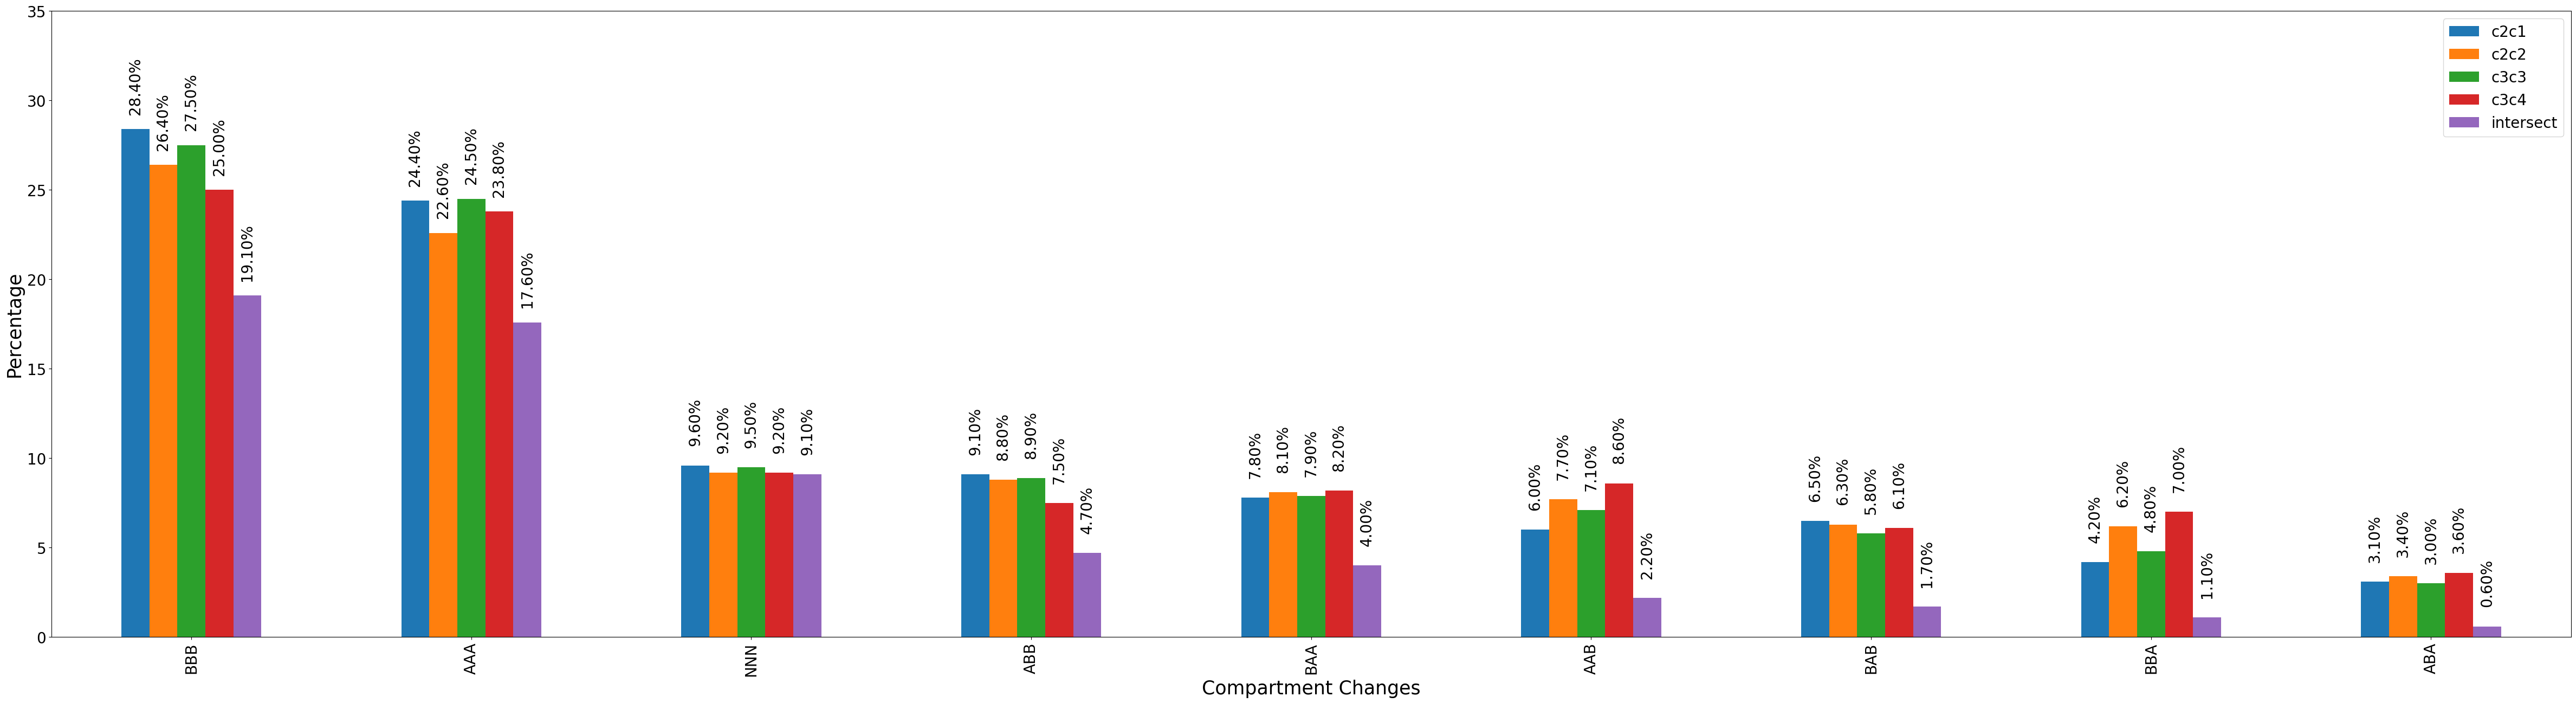

In [25]:
ax=c_percent.plot.bar(rot=90,figsize=(60, 15))
for p in ax.patches:
    value = p.get_height()
    if not pd.isna(value):
        ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()+2),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points',rotation=90,fontsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=20)
ax.set_ylim(0, 35)
ax.set_xlabel('Compartment Changes', fontsize=25)
ax.set_ylabel('Percentage', fontsize=25)
#plt.savefig("cooltools54/Comp-transitions/Patients-compartment-changes-top9.pdf")
plt.show()

## Getting lists for genes

#Run only once to create the file
gtf = pd.read_csv("gencode.v46.annotation.gtf",skiprows=5,sep='\t',names=['chrom','source','type','start','end','6','7','8','9'])
gtf.head()
len(gtf)
gtf['GeneName'] = gtf['9'].str.extract(r'gene_name "([^"]+)"')
gtf.head()
genes = gtf[gtf['type']=='gene'][['chrom','start','end','GeneName']]
len(genes)
genes.head()
genes.to_csv("gencode.v46.genes.tsv",index=False,sep='\t')

In [47]:
genes = pd.read_csv("/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/gencode_v43_comprehensive.tsv",sep='\t')
genes.head()

,#name,chrom,start,end,gene_name
0,ENST00000684719.1,chr1,67092164,67134970,C1orf141
1,ENST00000371007.6,chr1,67092164,67231852,C1orf141
2,ENST00000371006.5,chr1,67092175,67127261,C1orf141
3,ENST00000475209.6,chr1,67092175,67127261,C1orf141
4,ENST00000371004.6,chr1,67092394,67134970,C1orf141


In [48]:
def get_genes(sel):
    all_genes = pd.DataFrame(columns=['chrom', 'start', 'end', 'gene_name'])
    cumsum=0
    for i, r in sel.iterrows():
        chrom = r['chrom']
        s = r['start']
        e = r['end']
        #print(chrom,s,e)
        #sel_genes = genes[(genes['chrom'] == chrom) & (genes['start'] >= s) & (genes['end'] <= e)]
        sel_genes = genes[(genes['chrom'] == chrom) & ( ((genes['start'] >= s) & (genes['start'] <= e)) | ((genes['end'] >= s) & (genes['start'] <= e)))]
        #print(sel_genes.head())
        cumsum=cumsum+len(sel_genes)
        #print(len(sel_genes))
        all_genes = pd.concat([all_genes, sel_genes], ignore_index=True)
    assert (len(all_genes)==cumsum) 
    print("Genes:",cumsum)
    return all_genes

In [49]:
controls = pd.read_csv("cooltools54/Comp-transitions/Controls-intersect_EV1_flipped_versions_v2_cut_off_005_no_adjacent.tsv",sep='\t')
controls.head()
cmps = controls.groupby(['comp'])['comp'].count().reset_index(name='count')
cmps.head()
l = cmps['comp'].to_list()
l

['AAA',
 'AAB',
 'AAN',
 'ABA',
 'ABB',
 'ABN',
 'ANA',
 'ANB',
 'BAA',
 'BAB',
 'BAN',
 'BBA',
 'BBB',
 'BBN',
 'BNA',
 'BNB',
 'NAA',
 'NAB',
 'NBA',
 'NBB',
 'NBN',
 'NNA',
 'NNB',
 'NNN']

In [50]:
cs=0
for t in l:
    print(t,end=":")
    sel = controls[controls.comp==t].iloc[:,:3]
    print(len(sel))
    cs=cs+len(sel)
    all_genes=get_genes(sel)
    all_genes['gene_name'].drop_duplicates().to_csv('cooltools54/Comp-transitions/Controls_EV1_flipped_versions_v2_gencode_v43_comprehensive_cut_off_005_no_adjacent'+t+'_genes.txt', index=False, header=False,sep='\t')
    print("Done: ",len(all_genes['gene_name'].drop_duplicates()))
print(cs)
assert(cs==len(controls))

AAA:4739
Genes: 111328
Done:  15274
AAB:831
Genes: 12389
Done:  2053
AAN:4
Genes: 18
Done:  7
ABA:205
Genes: 2853
Done:  397
ABB:1389
Genes: 11904
Done:  1576
ABN:2
Genes: 12
Done:  3
ANA:3
Genes: 40
Done:  8
ANB:5
Genes: 20
Done:  7
BAA:1377
Genes: 15738
Done:  2878
BAB:566
Genes: 5402
Done:  1129
BAN:4
Genes: 31
Done:  9
BBA:444
Genes: 4535
Done:  605
BBB:5735
Genes: 28786
Done:  4319
BBN:6
Genes: 37
Done:  8
BNA:6
Genes: 37
Done:  12
BNB:20
Genes: 121
Done:  40
NAA:69
Genes: 1368
Done:  231
NAB:16
Genes: 207
Done:  44
NBA:7
Genes: 155
Done:  34
NBB:51
Genes: 559
Done:  79
NBN:1
Genes: 8
Done:  1
NNA:1
Genes: 16
Done:  2
NNB:1
Genes: 4
Done:  1
NNN:2616
Genes: 7326
Done:  1750
18098


In [108]:
pats = pd.read_csv("cooltools54/Comp-transitions/Patients-intersect.tsv",sep='\t')
pats.head()
cmps = pats.groupby(['comp'])['comp'].count().reset_index(name='count')
cmps.head()
l = cmps['comp'].to_list()
l

['AAA',
 'AAB',
 'ABA',
 'ABB',
 'BAA',
 'BAB',
 'BBA',
 'BBB',
 'BNB',
 'NAA',
 'NBB',
 'NNA',
 'NNB',
 'NNN']

In [109]:
cs=0
for t in l:
    print(t,end=":")
    sel = pats[pats.comp==t].iloc[:,:3]
    print(len(sel))
    cs=cs+len(sel)
    all_genes=get_genes(sel)
    all_genes['GeneName'].drop_duplicates().to_csv('cooltools54/Comp-transitions/Patients_'+t+'_genes.txt', index=False, header=False,sep='\t')
    print("Done: ",len(all_genes['GeneName'].drop_duplicates()))
print(cs)
assert(cs==len(pats))

AAA:5070
Genes: 23195
Done:  19030
AAB:633
Genes: 2266
Done:  1948
ABA:183
Genes: 507
Done:  418
ABB:1352
Genes: 2713
Done:  2030
BAA:1151
Genes: 3709
Done:  3086
BAB:478
Genes: 1450
Done:  1268
BBA:315
Genes: 759
Done:  627
BBB:5488
Genes: 8565
Done:  5867
BNB:7
Genes: 59
Done:  58
NAA:14
Genes: 107
Done:  106
NBB:5
Genes: 21
Done:  21
NNA:2
Genes: 19
Done:  19
NNB:11
Genes: 54
Done:  54
NNN:2604
Genes: 3867
Done:  3321
17313


In [65]:
temp = controls[controls.comp=="ABA"].iloc[:,:3]
len(temp)

268

In [82]:
c1 = pd.read_csv("cooltools54/Comp-transitions/strict/Controls_ABA_genes.txt",names=['gene'])
c1=c1.drop_duplicates().sort_values(by='gene')
c1.head()

,gene
169,ABITRAM
132,ACTG1P14
11,ADH5P3
235,AKR1B1P5
25,ANKRD44-AS1


In [86]:
c2 = pd.read_csv("cooltools54/Comp-transitions/Controls_ABA_ucsc.tsv",sep='\t',names=['chrom','start','end','gene'],skiprows=1)
c2=c2.drop_duplicates(subset=['gene']).sort_values(by='gene')
c2.head()

,chrom,start,end,gene
359,chr9,104781005,104928155,ABCA1
374,chr9,108934399,108940954,ABITRAM
294,chr9,6834455,6835577,ACTG1P14
16,chr1,240170154,240171291,ADH5P3
9,chr1,222668012,222712491,AIDA


In [89]:
#not strict function
tmp_genes=get_genes(temp)
temp.to_csv("cooltools54/Comp-transitions/testing.tsv",index=False,header=False,sep='\t')
c3=tmp_genes.drop_duplicates(subset=['GeneName']).sort_values(by='GeneName')

Genes: 647


In [92]:
len(c1),len(c2),len(c3)

(274, 484, 499)

In [74]:
extras = set(c3['GeneName'].tolist()) - set(c2['gene'].tolist())

In [75]:
extras

{'AKR1E2',
 'AP1S3',
 'ATP6V1D',
 'DELEC1',
 'ENSG00000286415',
 'KCNMB2',
 'NAALADL2',
 'NAV3',
 'PCA3',
 'RAB27A',
 'SLC14A2',
 'SLC8A1-AS1',
 'ST7-OT4',
 'TNFSF8',
 'TPRG1'}